In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix , ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('heartt.csv')
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,68,0,0,166,215,0,0,101,0,0.2,2,2,1,0
1,58,0,1,134,158,0,1,110,1,1.0,1,3,1,0
2,44,0,2,168,256,1,0,131,0,3.2,0,2,1,1
3,72,1,0,109,249,0,0,150,1,0.2,0,1,1,0
4,37,0,0,153,235,0,0,147,0,3.4,2,2,2,0


In [3]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1995,71,1,0,126,198,1,1,97,0,3.8,0,2,3,1
1996,73,1,0,162,247,0,1,168,0,2.3,0,1,1,0
1997,78,0,0,158,179,0,1,115,0,0.7,2,0,2,0
1998,69,1,1,131,221,0,0,101,0,3.7,2,1,3,1
1999,40,1,1,146,252,0,1,132,1,3.5,1,1,2,1


In [4]:
# number of rows and columns in the dataset
heart_data.shape

(2000, 14)

In [5]:
# getting some info about the data
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2000 non-null   int64  
 1   sex       2000 non-null   int64  
 2   cp        2000 non-null   int64  
 3   trestbps  2000 non-null   int64  
 4   chol      2000 non-null   int64  
 5   fbs       2000 non-null   int64  
 6   restecg   2000 non-null   int64  
 7   thalach   2000 non-null   int64  
 8   exang     2000 non-null   int64  
 9   oldpeak   2000 non-null   float64
 10  slope     2000 non-null   int64  
 11  ca        2000 non-null   int64  
 12  thal      2000 non-null   int64  
 13  target    2000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 218.9 KB


In [6]:
# checking for missing values
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,54.760000,0.516500,1.456500,135.095000,233.945500,0.497500,0.474500,144.399500,0.514500,1.994000,1.003500,1.51350,1.979500,0.507000
std,14.270046,0.499853,1.125496,26.073605,48.985971,0.500119,0.499474,32.042367,0.499915,1.163491,0.809206,1.11015,0.815115,0.500076
min,30.000000,0.000000,0.000000,90.000000,150.000000,0.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
25%,42.000000,0.000000,0.000000,112.000000,192.000000,0.000000,0.000000,116.000000,0.000000,1.000000,0.000000,1.00000,1.000000,0.000000
50%,55.000000,1.000000,1.000000,135.000000,232.500000,0.000000,0.000000,143.500000,1.000000,2.000000,1.000000,2.00000,2.000000,1.000000
75%,67.000000,1.000000,2.000000,158.000000,276.000000,1.000000,1.000000,173.000000,1.000000,3.000000,2.000000,2.00000,3.000000,1.000000
max,79.000000,1.000000,3.000000,179.000000,319.000000,1.000000,1.000000,199.000000,1.000000,4.000000,2.000000,3.00000,3.000000,1.000000


In [8]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

target
1    1014
0     986
Name: count, dtype: int64

In [9]:
X = heart_data.drop(columns='target')
Y = heart_data['target']
print(Y)

0       0
1       0
2       1
3       0
4       0
       ..
1995    1
1996    0
1997    0
1998    1
1999    1
Name: target, Length: 2000, dtype: int64


In [10]:
#test and train split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2) 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 13) (1600, 13) (400, 13)


In [12]:
# training the LogisticRegression model with Training data
model = LogisticRegression(max_iter=1000,solver='liblinear',C=0.1)
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction,)
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.966875


In [14]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test,X_test_prediction)
print('Accuracy on Test data : ', test_data_accuracy)

Accuracy on Test data :  0.9775


In [15]:
input_data = (43,0,0,147,207,0,1,126,0,3.0,2,3,1)

# change the input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# scale the input data
input_data_reshaped = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
    print('The Person does not have a Heart Disease')
else:
    print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


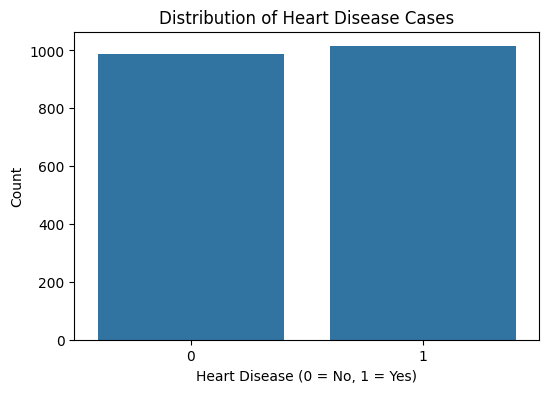

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=heart_data)
plt.title("Distribution of Heart Disease Cases")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [17]:
# Get predictions for test set
Y_pred = model.predict(X_test)

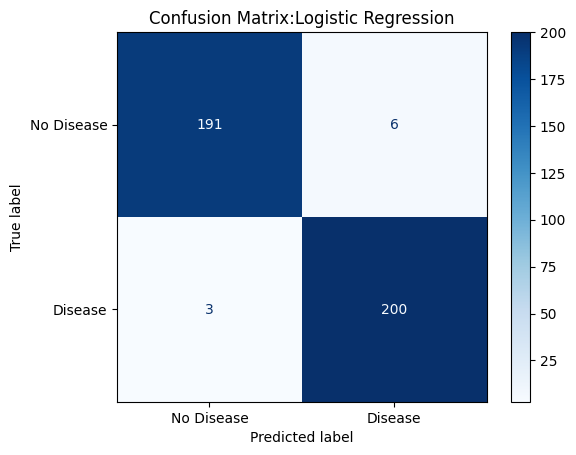

In [18]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix:Logistic Regression')
plt.show()

In [19]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)
dt_preds = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, Y_train)
rf_preds = rf.predict(X_test)

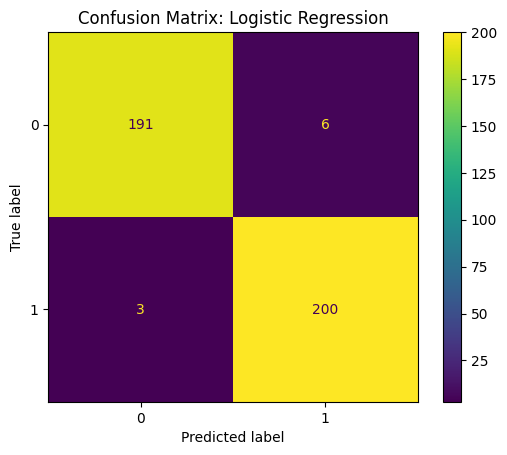

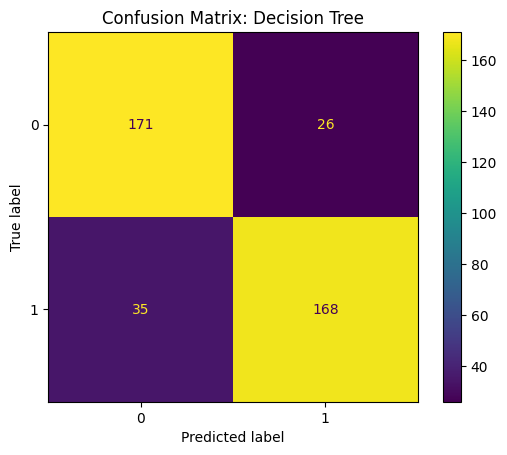

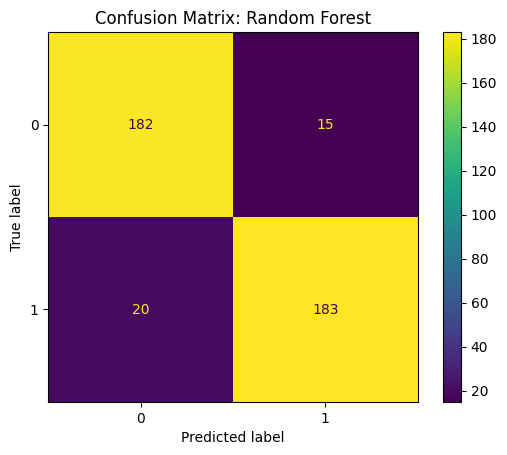

In [20]:
models = {
    "Logistic Regression": (model, X_test),
    "Decision Tree": (dt, X_test),
    "Random Forest": (rf, X_test)
}

for model_name, (model, X_data) in models.items():
    preds = model.predict(X_data)
    cm = confusion_matrix(Y_test, preds)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": model,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, m in models.items():
    y_pred = m.predict(X_test)
    
    precision = precision_score(Y_test, y_pred)
    recall    = recall_score(Y_test, y_pred)
    f1        = f1_score(Y_test, y_pred)
    
    print(f"Model: {name}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print("---")

Model: Logistic Regression
Precision : 0.9242
Recall    : 0.9015
F1 Score  : 0.9127
---
Model: Decision Tree
Precision : 0.8660
Recall    : 0.8276
F1 Score  : 0.8463
---
Model: Random Forest
Precision : 0.9242
Recall    : 0.9015
F1 Score  : 0.9127
---
